# Introduction to Regression

What is a regression? At its most basic, it is a method of fitting some data, $X$ that can explain / predict some dependent data $Y$. Note that regressions tend to model data that has a continuous outcome (discrete outcomes are part of another set of methods that tend to be known as classification or Generalised Linear Models). 

But for now, we want to learn (or model) how a set of features in $X$ relate to an outcome $Y$. Simple enough to start. The canonical linear model tends to be described as: 

$$ y = X\beta + u $$

The crucial element for the above model is the error term, $u$. This error term allows us to estimate a relationship between $Y$ and $X$. The crucial assumption behind this error term is that it is normally distirbuted i.e. $u ~ N(0,1)$, or in words the error term follows a normal distribution with a mean of zero and a standard deviation of one. This assumption allows us to find a solution to the model by minimising the sum of squared residuals. 

So explore how we can estimate this relationship that tends to be represented by the vector $\beta$.

I will be exploring linear models in matrix notation because I tend to find it much easier and less tedious. This also allows us to then focus in it’s interpretation and implementation.

However, in order for us to be on the same page when using matrix notation, we need to get the basic tedious background of matrix notation out of the way (once that's done everything will be much neater)! 

So let's do a quick refresh on matrices.

## A (very) brief introduction to linear models in matrix form

###  what even is a matrix?
Firstly, what is a matrix? 

Well, a matrix is a rectangular array of numbers with dimensions $r \times c$.
- A matrix is **square** if $r = c$ i.e. there are the same number of row and columns.
- A matrix is **symmetrical** if $a_{ij} = a_{ji} \quad \forall i,j$ i.e. the elements in the row i column j is identical to the elements in row j column i.

A general matrix is represented by an upcase letter such as $X$ and takes the form:
$$
X = \begin{bmatrix}
a_{11} & a_{12} & \cdots & a_{1c} \\
a_{21} & a_{22} & \cdots & a_{2c} \\
a_{31} & a_{32} & \cdots & a_{3c} \\
\vdots & \vdots & \ddots & \vdots \\
a_{r1} & a_{r2} & \cdots & a_{rc}
\end{bmatrix}
$$

So far so good. Nothing to complex. But now lets get some other basic concepts behind matrices under out belts.

#### The  Diagonal
The main (or principal) diagonal of a square matrix (where $r=c$) can be represented by:
$$ \text{diag}(A) = (a_{11}, a_{22}, a_{33}, \dots, a_{cc}) $$

#### A Diagonal Matrix
The diagonal itself can also be represented as a matrix and is known as a **diagonal matrix** if $a_{ij} = 0 \quad \forall i \neq j$ i.e. all elements where $i \neq j$ are zero. For example:

$$
X = \begin{bmatrix}
a_{11} & 0 & 0 & \cdots & 0 \\
0 & a_{22} & 0 & \cdots & 0 \\
0 & 0 & a_{33} & \cdots & 0 \\
\vdots & \vdots & \vdots & \ddots & \vdots \\
0 & 0 & 0 & \cdots & a_{cc}
\end{bmatrix}
$$

#### Identity Matrix
The above matrix is an **identity matrix**, $I_n$, if the $n \times n$ matrix diagonal has $a_{ii} = 1, \quad \forall i=1,\dots,n$ i.e. all the diagonals are equal to one

### Matrix Operations
Cool we've got the very basics for matrices under our belts! Now lets see how we can use matrices to make some transformations!

#### Addition and Subtraction
To add or subtract matrices, the dimensions of each matrix must be identical.
*   $A = B$ if $a_{ij} = b_{ij} \quad \forall i,j$
*   $C = A + B = [a_{ij} + b_{ij}]$

So say you want to add two matrices together, the elements will add together corrsepondingly as such:

$$
X = \begin{bmatrix}
a_{11}+b_{11} & a_{12}+b_{12} & \cdots & a_{1c}+b_{1c} \\
a_{21}+b_{21} & a_{22}+b_{22} & \cdots & a_{2c}+b_{2c} \\
a_{31}+b_{31} & a_{32}+b_{32} & \cdots & a_{3c}+b_{3c} \\
\vdots & \vdots & \ddots & \vdots \\
a_{r1}+b_{r1} & a_{r2}+b_{r2} & \cdots & a_{rc}+b_{rc}
\end{bmatrix}
$$

Okay not to bad, just summing across the columns. nice.

#### Transpose
Another really handy operation is transposition. To transpose a matrix is to flip the rows and columns. This becomes really helpful when we want to solve systems of equations. For a matrix $A$, the convention is to denote the transpose as  $A'$ or $A^T$.
- By definition: $A = (A')'$ i.e. a matrix transposed twice is itself.
- If $A$ is $(r \times c)$, then $A'$ is $(c \times r)$ i.e. the rows and columns are flipped.
- $A$ is **symmetric** if $A = A'$ i.e. flipping the rows and columns doesn't change the matrix. 

#### Vectors
Now vectors are really helpful because they're basically small matrices. If you've ever done linear algebra, firstly why are you reading this, but secondly you'll know they are the basis of linear algebra! 

For our purposes, it's probably most helpful to imagine a vector as either a
- A **row vector** is a $1 \times c$ matrix; or,
- A **column vector** ($r \times 1$).

Below is an example of a row and column matric (vector) respectively:

$$
\quad x = (x_1, x_2, \dots, x_c), x' = \begin{pmatrix} x_1 \\ x_2 \\ \vdots \\ x_r \end{pmatrix}
$$

For our purposes it can kind of helpful to think of a vector as a single dimension list that contains a set amount of elements, for example a list of parameters in a linear model $\beta$.

#### Inner Product
Taking the inner product of two vectors results in a scalar i.e. a $1 \times 1$ matrix. The inner product of a $1 \times k$ row vector and a $k \times 1$ column vector is defined as:

$$
x'\beta = (x_1, x_2, \dots, x_k) \begin{pmatrix} \beta_1 \\ \beta_2 \\ \vdots \\ \beta_k \end{pmatrix} = \sum_{j=1}^k x_j \beta_j
$$

Note that they have to be of the same length in order to take an inner product.

#### Matrix Decomposition
As we explored above, matrices can be viewed as rows of $k$ vectors or columns of $n$ vectors. 

This means we can actually represent matrices as vectors, where each element inside the vector is itself a vector. This becomes really handy when simplifying notation of large matrices. 

For example, we can represent a square matrix as a row vector that contains column vectors:
$$
X = \begin{bmatrix} a_{11} & \cdots & a_{1c} \\ \vdots & \ddots & \vdots \\ a_{r1} & \cdots & a_{rc} \end{bmatrix} = \begin{bmatrix} \mathbf{a}_1 & \mathbf{a}_2 & \cdots & \mathbf{a}_c \end{bmatrix}
$$

Or we can represent a square matrix as a column vector that contains a row vectors:
$$
X = \begin{bmatrix} a_{11} & \cdots & a_{1c} \\ \vdots & \ddots & \vdots \\ a_{r1} & \cdots & a_{rc} \end{bmatrix} = \begin{pmatrix} \mathbf{a}^1 \\ \mathbf{a}^2 \\ \vdots \\ \mathbf{a}^r \end{pmatrix}
$$

This becomes handy later when we look at panel data. 

#### Multiplication

The big operation, multilpication. Unlike addition, multiplying matrices can get quite tedious (good thing we have computers).

To multiply a matrix, the number of rows in $A_{(n \times p)}$ must equal the number of columns in $B_{(p \times q)}$. 

The result is a matrix $C_{(n \times q)}$ (not that the dimension of matrix $C$ is the rows of matrix $A$, $n$, and the columns of matrix $B$, $q$ i.e. $n \times q$.

Say we multiply two vectors that have stacked matrices we would get:
$$
AB = (a_{n1}, \dots, a_{np}) \begin{pmatrix} b_{1q} \\ \vdots \\ b_{pq} \end{pmatrix} = \sum_{j=1}^p a_{nj} b_{jq} = c_{nq}
$$

##### Vector Multiplication
When multiplying a $u_{(n \times 1)}$ vector, the result depends on the order of multiplication:

- **Scalar Result ($u'u$):**
    $$
    u'u = (u_1, \dots, u_n) \begin{pmatrix} u_1 \\ \vdots \\ u_n \end{pmatrix} = \sum_{i=1}^n u_i^2 = \text{scalar}
    $$

*Note: When $u$ is a regression error term, $u'u$ is the Sum of Squared Errors. This will be really helpful in solving for $\beta$*

- **Matrix Result ($uu'$):**
    $$
    uu' = \begin{pmatrix} u_1 \\ \vdots \\ u_n \end{pmatrix} (u_1, \dots, u_n) = \begin{bmatrix}
    u_1^2 & u_1 u_2 & \cdots & u_1 u_n \\
    u_2 u_1 & u_2^2 & \cdots & u_2 u_n \\
    \vdots & \vdots & \ddots & \vdots \\
    u_n u_1 & u_n u_2 & \cdots & u_n^2
    \end{bmatrix}_{n \times n}
    $$

*Note: $uu'$ is the variance-covariance matrix of errors (unnormalized) - this is helpful in calculating the standard errors and in turn hypothesis testing.*

#### Weighted Sum of Squares
If a matrix $W_{(n \times n)}$ is diagonal, the product involving $u'_{(1 \times n)}$ and $u_{(n \times 1)}$ is the weighted sum of squares:
$$
u'Wu = (u_1, \dots, u_n) \begin{bmatrix}
w_1 & 0 & \cdots & 0 \\
0 & w_2 & \cdots & 0 \\
\vdots & \vdots & \ddots & \vdots \\
0 & 0 & \cdots & w_n
\end{bmatrix} \begin{pmatrix} u_1 \\ \vdots \\ u_n \end{pmatrix} = \sum_{i=1}^n w_i u_i^2
$$

This becomes quite helpful when handling data that has changing / increasing variance (known in the biz as heteroskedasticity). For now, when it comes to estimating $\beta$, we can use ordinary leaset squares (OLS) minimises the sum of squared residuals i.e. $u'u$. For a more general solution we can use generalised least squares minimises a weighted version of the sum of squared residuals i.e. $u'W'u$ (and in the process can handle heteroskedasticity issues).

OLS and GLS are identical when the matrix $W$ is an identity matrix. 

#### Matrix Inversion
Now the last transformation we need to be able to estimate $\beta$ is known as matrix inversion. 

For a scalar $a$, the inverse is $a^{-1} = 1/a$ such that $a \times a^{-1} = 1$ (if $a \neq 0$).

For a $k \times k$ matrix $A$, the inverse $A^{-1}$ exists if and only if $A^{-1}A = I_k$ and $AA^{-1} = I_k$.

**Conditions:**
- $A$ is **invertible** $\iff |A| \neq 0 \iff \text{rank}(A) = k$
- $A$ is **singular** $\iff |A| = 0 \iff \text{rank}(A) < k$

*(Where $|A|$ is the determinant and $\text{rank}(A)$ is the matrix rank - don't worry about these concepts for now).*

It might be helpful to think of inversion as an analog for the operation of division in a scalar setting. 

It is most certainly not the same thing, but when we multiply an inverted matrix by its original, we get the identity matrix. This makes solving linear systems really simple because it can cancel out terms on the other side of equations. This will actually be a key part of estimating $\beta$.

But first, lets note down some important properties of inverse matrices:

- If a matrix has an inverse, it is **unique**.
- $(\alpha A)^{-1} = \frac{1}{\alpha}A^{-1}$ for scalar $\alpha \neq 0$ (if $A^{-1}$ exists) i.e. inversion of scalars is similar to division.
- $(A^{-1})^{-1} = A$ i.e. applying inversion to an inverted matrix returns the original matrix.
- $(A')^{-1} = (A^{-1})'$ .i.e transposing inside or outside the inersion is identical.
- $(AB)^{-1} = B^{-1}A^{-1}$ (where both are square and invertible) i.e. inversion to multiplied matrices inverts both those matrices.   

Now that we've well and truly covered the very basics, lets apply this to regressions themselves!

### Regression Applications

#### Identification

Typically, a matrix $X$ is not square. Usually there are many more rows than columns.

In fact, we need $n > k$ to identify and estimate a linear regression model i.e. we need at least as many rows as parameters, also known as degrees of freedom.

However, we can use some of the transformations explored above to tidy things up a bit, notably multiplication:
- The product $X'_{(k \times n)}X_{(n \times k)}$ is a **square** $k \times k$ symmetric matrix.
- The product $X'y$ is a $k \times 1$ column vector.

These two products will be the building blocks of OLS. 

#### The Identity Vector, the sample mean and centering a matrix
Now, just like there is an identity matrix, there is also an identity vector (a column vector of 1s):

$$
\mathbf{i}_{(n \times 1)} = \begin{pmatrix} 1 \\ 1 \\ \vdots \\ 1 \end{pmatrix}
$$

Taking the inner product of the identity vector returns the length of that vector .i.e.  $\mathbf{i}'\mathbf{i} = n$.

Multiplying a new vector by the identify vector acts like summinng up that vector .i.e. $\mathbf{i}'x_{(n \times 1)} = \sum x_i$.

This bceomes really handy when it comes to calculating the sample mean. We can express the sample mean using the identify vector as:

$$
(\mathbf{i}' \mathbf{i})^{-1}\mathbf{i}'x = \frac{1}{n}\sum x_i = \bar{x}
$$

#### Centering (Demeaning) a Matrix

Another really handy property of the identify matrix is we can create a **centering matrix**. 

If we take the outer product of the vectors the result will be a matrix of $1/n$:

$$
(\mathbf{i}' \mathbf{i})^{-1}\mathbf{i}\mathbf{i}' = \begin{bmatrix} 1/n & \cdots & 1/n \\ \vdots & \ddots & \vdots \\ 1/n & \cdots & 1/n \end{bmatrix}
$$

Since $x = Ix$, we can center data using this matrix, often denoted as $M^0$:
$$
\begin{pmatrix} x_1 - \bar{x} \\ x_2 - \bar{x} \\ \vdots \\ x_n - \bar{x} \end{pmatrix} = [x - (\mathbf{i}' \mathbf{i})^{-1} \mathbf{i} \mathbf{i}' x] = [I - (\mathbf{i}' \mathbf{i})^{-1} \mathbf{i} \mathbf{i}']x = M^0x
$$
Where $M^0$ is:
$$
M^0 = I - (\mathbf{i}' \mathbf{i})^{-1}\mathbf{i}\mathbf{i}' = \begin{bmatrix}
1-1/n & -1/n & \cdots & -1/n \\
-1/n & 1-1/n & \cdots & -1/n \\
\vdots & \vdots & \ddots & \vdots \\
-1/n & -1/n & \cdots & 1-1/n
\end{bmatrix}
$$
$M^0$ is **symmetric** and **idempotent** ($M^0 M^0 = M^0$). 

This is a really handy property for a matrix to have. Once we go through panel data we will see how helpful this matrix can be at transforming our data. 

#### Sum of Squared Deviations
Let's use this $M^0$ matrix to derive the sum of squared deviations:
$$
\sum_{i=1}^n (x_i - \bar{x})^2 = (M^0 x)'(M^0 x) = x'M^{0'}M^0x = x'M^0x
$$
Similarly for covariance:
$$
\sum_{i=1}^n (x_i - \bar{x})(y_i - \bar{y}) = x'M^0y
$$

#### Solving for $\beta$ (OLS Estimator)
So, we've finally got to the point end, lets estimate that coefficient! Just as a reminder, we're estimating $\beta$ from the below model:

$$ y = X\beta+u$$

We solve for $\beta$ by multiplying $(X'X)^{-1}$ to both sides of the normal equation $X'y = X'X\hat{\beta} + x'u$ (note who the $X'X$ product is there to make sure the matrix is square and hence why a random X' is on the left hand side of the equation):
$$
(X'X)^{-1} X'y = (X'X)^{-1} X'X\hat{\beta} + x'u
$$

It's worth nothing now that $(X'X)^{-1} X'X$ creates the identity matrix because any matrix multiplied by its inverse is the identity matrix. Therefore, we can say:

$$
\Rightarrow (X'X)^{-1} X'y = I\hat{\beta} = \hat{\beta}
$$
Thus, the OLS estimator is: 

$$ \hat{\beta} = (X'X)^{-1} X'y$$

Okay we finally got there! 

Note it probabky looks like the $u$ has just randomly dissapeared. But if you remember all the way back at the start we have assumed that $u ~ N(0,1)$ i.e. it has a mean of zero. So when we multiply $u$ by $(X'X)^{-1}$ it will equal zero and hence simply drops out of the above formula. 

Now crucially this is an assumption, and it's a big one! Infact, a lot of econometrics is doing tests to ensure that this assumption is true. 

For more on the derivation of OLS feel free to browse this explanation: https://www.stat.cmu.edu/~cshalizi/mreg/15/lectures/13/lecture-13.pdf.

However, now that we know how to estimate a linear regression, lets do some exercises! 

## Tutorial Exercise

Firstly, lets load in the necessary packages we will need for these exercises.

In [1]:
%reset -f

In [2]:
import pandas as pd # great dataframe pacakge
import numpy as np # helpful package for linear algebra
import statsmodels.api as sm # helpful package to model ols

Great now lets load in some data for us to play around with. 

This dataset is a very simple collection of house sales. We will try to model some prices to see which features of houses are most important in determining prices (as well as how helpful they are at predicting house prices).

In [3]:
df = pd.read_csv('https://raw.githubusercontent.com/Michael-Morgan-Giles/regression_analysis/refs/heads/main/data/hprice1.csv')

We can print the columns to see what covariates we have available to use in the model.

In [4]:
df.columns

Index(['price', 'assess', 'bdrms', 'lotsize', 'sqrft', 'colonial', 'lprice',
       'lassess', 'llotsize', 'lsqrft'],
      dtype='object')

We can also print some of the key info relating to the data frame.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 88 entries, 0 to 87
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   price     88 non-null     float64
 1   assess    88 non-null     float64
 2   bdrms     88 non-null     int64  
 3   lotsize   88 non-null     int64  
 4   sqrft     88 non-null     int64  
 5   colonial  88 non-null     int64  
 6   lprice    88 non-null     float64
 7   lassess   88 non-null     float64
 8   llotsize  88 non-null     float64
 9   lsqrft    88 non-null     float64
dtypes: float64(6), int64(4)
memory usage: 7.0 KB


We can also see how big the dataset is. There are 88 observations and 10 columns (i.e. potential covariates we can estiamte parameters for).

In [6]:
df.shape

(88, 10)

Whilst I didn't go through why it's important, it can be helpful to quickly look at the descriptive statistics to get an idea of your data before modelling. 

Whilst this is a little beyond the scope of this notebook, it is really easy to achieve in python. For example, we can get the key summary stats by using `.describe()`:

In [7]:
df.describe()

,price,assess,bdrms,lotsize,sqrft,colonial,lprice,lassess,llotsize,lsqrft
count,88.000000,88.000000,88.000000,88.000000,88.000000,88.000000,88.000000,88.000000,88.000000,88.000000
mean,293.546034,315.736362,3.568182,9019.863636,2013.693182,0.693182,5.633180,5.717994,8.905104,7.572610
std,102.713445,95.314435,0.841393,10174.150414,577.191583,0.463816,0.303573,0.262113,0.544060,0.258688
min,111.000000,198.700000,2.000000,1000.000000,1171.000000,0.000000,4.709530,5.291796,6.907755,7.065613
25%,230.000000,253.900002,3.000000,5732.750000,1660.500000,0.000000,5.438079,5.536940,8.653908,7.414873
50%,265.500000,290.199995,3.000000,6430.000000,1845.000000,1.000000,5.581613,5.670567,8.768719,7.520231
75%,326.250000,352.125000,4.000000,8583.250000,2227.000000,1.000000,5.787642,5.863982,9.057567,7.708266
max,725.000000,708.599980,7.000000,92681.000000,3880.000000,1.000000,6.586172,6.563291,11.436919,8.263591


We can also visualise things such as the distribution of the outcome variable.

<AxesSubplot: >

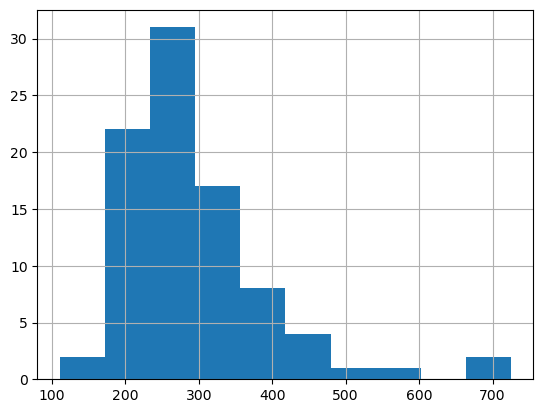

In [8]:
df['price'].hist()

But enough messing around, let's try estimate that a model. 

Let's just start really simply by using the formula we derived above! This will involve creating a function that we can call again later. 

In [9]:
def ols(y,X):
    return np.dot(np.linalg.inv(np.dot(X.T,X)), np.dot(X.T,y))

If you've never used `numpy` before that might look a little confusing. But it is just the formula we saw above that takes two inputs, a vector $y$ and a matrix $X$. 

Let's put it to the test! I would guess that the number of bedrooms a house has has a strong relationship to its prices, so lets test out this theory. 

I will put in the column (vector) `df['price']` into the `y` arguement, and the matrix `df[['bdrms']].assign(const = 1)` into the `X` arguement to estimate $\beta$ (not i've added a vector of 1's so we estimate the intercept $\beta$).

In [10]:
ols(df['price'], df[['bdrms']].assign(const = 1))

array([62.02456397, 72.23111252])

Um, okay did it work? 

Well if we're to believe what that vector says, then a house with no bedrooms has a price of ~$\$72,000$ (lol omg this dataset is old). For every extra bedroom the house has, we can expect the price to rise by ~$\$62,000$.

Okay that generally supports my hypothesis. But how about we use some code that actually good coders (not me) has made. For this we can use `statsmodels` and open source package for all your statistical modelling needs! 

Let's estimate the model using the function `.OLS()` and see if we get the same estimate.

In [11]:
print(sm.OLS(df['price'], df[['bdrms']].assign(const = 1)).fit().summary())


                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.258
Model:                            OLS   Adj. R-squared:                  0.250
Method:                 Least Squares   F-statistic:                     29.93
Date:                Fri, 19 Jun 2026   Prob (F-statistic):           4.34e-07
Time:                        17:20:07   Log-Likelihood:                -518.84
No. Observations:                  88   AIC:                             1042.
Df Residuals:                      86   BIC:                             1047.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
bdrms         62.0246     11.338      5.470      0.0

Yay, they're the same! But you can see from the print out that there is a whole lot more helpful information included that my little function doesn't provide. 

Whilst some of these are beyond the scope of this notebook, know how to access them from thie object can be really helpful. 

To get the vector of coefficients you can use:

In [12]:
sm.OLS(df['price'], df[['bdrms']].assign(const = 1)).fit().params

bdrms    62.024564
const    72.231113
dtype: float64

To get the error's variance estimate you can use:

In [13]:
sm.OLS(df['price'], df[['bdrms']].assign(const = 1)).fit().scale

7917.574546111831

You can extract the $t$-values:

In [14]:
sm.OLS(df['price'], df[['bdrms']].assign(const = 1)).fit().tvalues

bdrms    5.470486
const    1.738278
dtype: float64

You can extract the $R^2$:

In [15]:
sm.OLS(df['price'], df[['bdrms']].assign(const = 1)).fit().rsquared

0.25814885946674593

And generally all the other interesting things stored in the model object. 

For a full list check out the statsmodel documentation here: https://www.statsmodels.org/stable/generated/statsmodels.regression.linear_model.OLSResults.html.

But now that we've seen how to estimate a model, perhaps we should use this model to predict some house prices? 

Luckly, `statsmodel` has a helpful inbuilt prediction function so we don't have to code up the linear algebra ourselves!

Say we want to know the price of a bedroom with three bedrooms? Well we can calculate that below:

In [16]:
sm.OLS(df['price'], df[['bdrms']].assign(const = 1)).fit().predict([3, 1])

array([258.30480445])

So a house with three bedrooms will cost around $\$258,000$ (oh my god this dataset is really out of date). 

This is great and all, but you will see from the $R^2$ that this model doesn't do a great job explaining all the variance in the data. So, perhaps we can make it a bit better (and also code it up in a less janky fashion).

In [17]:
df.columns

Index(['price', 'assess', 'bdrms', 'lotsize', 'sqrft', 'colonial', 'lprice',
       'lassess', 'llotsize', 'lsqrft'],
      dtype='object')

I like to create lists of the variables in one place so they're easier to update if you create a lot of models.

In [18]:
y = 'price'
X = ['assess', 'bdrms', 'sqrft', 'lotsize', 'colonial']

you can also save the model as an object so you don't need to run it everytime (sweat).

In [19]:
better_mod = sm.OLS(df[y], sm.add_constant(df[X])).fit()

now you can use that object to extract the things you need like the model output.

In [20]:
print(better_mod.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.831
Model:                            OLS   Adj. R-squared:                  0.821
Method:                 Least Squares   F-statistic:                     80.56
Date:                Fri, 19 Jun 2026   Prob (F-statistic):           3.59e-30
Time:                        17:20:07   Log-Likelihood:                -453.78
No. Observations:                  88   AIC:                             919.6
Df Residuals:                      82   BIC:                             934.4
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -40.4477     21.594     -1.873      0.0

Okay this model is starting to look a little more reasonable. The $R^2 > 0.8$ such that it's fitting the data a lot better. 

Let's try use this to calculate a three bedroom house that has the average values for assess, lotsize and is not a colonial era building. 

In [23]:
better_mod.predict([1, 
                    df['assess'].mean(),
                   3,
                   df['sqrft'].mean(),
                    df['lotsize'].mean(),
                   0])

array([281.45609486])

The model now suggests the price for an average 3 bedroom non-colonial house is about $\$30K$ higher than the simpler model.

Now that's great and all, but prediction is more the realms of data science (and there are much better models to use than linear regression). 

What is interesting about this output from an economic perspective is that only the assessment value of the house is a statistically significant predictor of the price (only one with a `p-value` less than 0.01). 

Interestingly, it suggests that for every $\$1$ increase in the assessment price, you can only expect a rougly $\$0.90$ increase in the actual price! 

Interesting. This is where a nice "trick" in a linear model can be used to estimate an elasticity between $X$ and $Y$ i.e. for a \% change in $X$ we can expect a \% change in $y$.

Now if you're not familiar with elasticities, give the wikipedia a read. But the basics of how to estimate an elasticity using a linear model goes like this. We have a log-log model:

$$ \ln Y = \ln X \beta + u$$

If we take the derivative of this model w.r.t $X$ we get: 

$$ \frac{\partial Y}{\partial X} \frac{1}{Y} = \frac{1}{X}\beta $$

If we rearrange this, you will notice that this is the expression of an elasticity:

$$ \beta = \frac{\partial Y}{\partial X} \frac{X}{Y} $$

What this means is that this coefficeint can be interpreted as an elasticity i.e. a 1\% change in $X$, leads to a $\beta$\% change in $Y$. 

Okay, lets test this by replace the variables in the above model with their natural log. 

*(note because bedrooms and colonials are either a count of binary variable, taking their log doesn't really make to much sense, so i've just left them untransformed)*

$$ \ln Y = \beta T + \varepsilon,  \ where \ T \in 0,1$$ 

In [24]:
mod_log = sm.OLS(df['lprice'], sm.add_constant(df[['bdrms', 'lassess', 'llotsize', 'lsqrft', 'colonial']])).fit()

In [25]:
print(mod_log.summary())

                            OLS Regression Results                            
Dep. Variable:                 lprice   R-squared:                       0.777
Model:                            OLS   Adj. R-squared:                  0.763
Method:                 Least Squares   F-statistic:                     57.15
Date:                Fri, 19 Jun 2026   Prob (F-statistic):           2.71e-25
Time:                        17:20:46   Log-Likelihood:                 46.576
No. Observations:                  88   AIC:                            -81.15
Df Residuals:                      82   BIC:                            -66.29
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2097      0.569      0.368      0.7

The model is now showing that prices is elastic to the assessment price i.e for a 1\% increase in the assessed price, we can expected an ~1.03\% increase in the actual price! 

Again, this is the only statistically significant variable in the model. Suggesting that it is not always the features of the property that impact its price, but rather how much it's assessed value is (damn real estate agents)!

Anyhow, this has been a very rudimentary introduction to regressions. I hope it's been helpful to you and you! 